In [1]:
!pip install torch


[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
PATH = "../Datasets/UCI Dynamic Gas Mixtures"

In [3]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [4]:
class BaselineLSTM(nn.Module):
    def __init__(self, channels):
        super().__init__()

        self.channels = channels

        self.pooling = nn.AvgPool1d(kernel_size=5, stride=5)

        self.cnn = nn.Sequential(
            nn.Conv1d(in_channels=self.channels, out_channels=32, kernel_size=7, padding=3),
            nn.ReLU(),
            nn.Conv1d(in_channels=32, out_channels=64, kernel_size=5, stride=2, padding=2),
            nn.ReLU(),
            nn.Conv1d(in_channels=64, out_channels=64, kernel_size=5, stride=2, padding=2),
            nn.ReLU(),
        )

        self.lstm = nn.LSTM(input_size=64, hidden_size=64, num_layers=1, batch_first=True, bidirectional=False)

        self.lin_head = nn.Linear(in_features=64, out_features=2)

    def forward(self, x):
        x = self.pooling(x)
        x = self.cnn(x)
        x = x.transpose(1, 2)
        _, (h, _) = self.lstm(x)
        x = h[-1]
        pred = self.lin_head(x)
        return pred

In [5]:
model = BaselineLSTM(channels=16)

In [6]:
x = torch.randn(4, 16, 5000)
y = model(x)

print(y.shape)
assert y.shape == torch.Size([4, 2])
print("се ок")

torch.Size([4, 2])
се ок


In [7]:
X = pd.read_csv(PATH + "/ethylene_CO.txt", sep=r'\s+', skiprows=1, names=['Time', 'Co', 'Ethylene'] + [f's{i}' for i in range(1, 17)])

In [8]:
X

,Time,Co,Ethylene,s1,s2,s3,s4,s5,s6,s7,s8,s9,s10,s11,s12,s13,s14,s15,s16
0,0.00,0.0,0.0,-50.85,-1.95,-41.82,1.30,-4.07,-28.73,-13.49,-3.25,55139.95,50669.50,9626.26,9762.62,24544.02,21420.68,7650.61,6928.42
1,0.01,0.0,0.0,-49.40,-5.53,-42.78,0.49,3.58,-34.55,-9.59,5.37,54395.77,50046.91,9433.20,9591.21,24137.13,20930.33,7498.79,6800.66
2,0.01,0.0,0.0,-40.04,-16.09,-27.59,0.00,-7.16,-42.14,-12.52,-5.86,53960.02,49299.30,9324.40,9449.81,23628.90,20504.94,7369.67,6697.47
3,0.03,0.0,0.0,-47.14,-10.57,-32.28,4.40,-11.22,-37.94,-7.16,-1.14,53047.71,48907.00,9170.64,9305.58,23101.66,20101.42,7285.13,6578.52
4,0.04,0.0,0.0,-33.58,-20.79,-33.25,6.03,3.42,-34.22,-14.46,8.31,52700.28,48330.96,9073.64,9163.47,22689.54,19694.07,7156.74,6468.32
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4208256,42087.51,0.0,0.0,1127.81,105.93,2117.39,2247.58,1207.59,1646.73,2089.97,2262.98,1061.70,1070.47,2570.33,2073.57,709.06,775.36,2513.75,1848.65
4208257,42087.52,0.0,0.0,1140.73,96.46,2105.93,2253.69,1216.39,1624.47,2073.57,2246.61,1063.89,1075.26,2580.88,2083.78,698.24,768.93,2511.20,1843.63
4208258,42087.53,0.0,0.0,1123.99,107.92,2111.18,2245.63,1215.36,1628.44,2085.45,2271.80,1059.31,1063.49,2583.20,2090.20,709.62,775.73,2510.18,1841.80
4208259,42087.54,0.0,0.0,1131.44,111.08,2114.76,2249.54,1197.99,1612.17,2078.32,2272.29,1063.69,1066.08,2578.56,2100.92,716.72,779.14,2508.91,1851.17


In [9]:
time = X["Time"].to_numpy()
y = X[["Co", "Ethylene"]].to_numpy(dtype=np.float32)
X = X[[f"s{i}" for i in range(1, 17)]].to_numpy(dtype=np.float32)

In [10]:
X

array([[-5.085000e+01, -1.950000e+00, -4.182000e+01, ...,  2.142068e+04,
         7.650610e+03,  6.928420e+03],
       [-4.940000e+01, -5.530000e+00, -4.278000e+01, ...,  2.093033e+04,
         7.498790e+03,  6.800660e+03],
       [-4.004000e+01, -1.609000e+01, -2.759000e+01, ...,  2.050494e+04,
         7.369670e+03,  6.697470e+03],
       ...,
       [ 1.123990e+03,  1.079200e+02,  2.111180e+03, ...,  7.757300e+02,
         2.510180e+03,  1.841800e+03],
       [ 1.131440e+03,  1.110800e+02,  2.114760e+03, ...,  7.791400e+02,
         2.508910e+03,  1.851170e+03],
       [ 1.130230e+03,  9.845000e+01,  2.107120e+03, ...,  7.725200e+02,
         2.530080e+03,  1.864440e+03]], shape=(4208261, 16), dtype=float32)

In [11]:
y

array([[0., 0.],
       [0., 0.],
       [0., 0.],
       ...,
       [0., 0.],
       [0., 0.],
       [0., 0.]], shape=(4208261, 2), dtype=float32)

In [12]:
def find_segments(target):
    changed = np.any(target[1:] != target[:-1], axis=1)

    boundaries = np.concatenate([
        [0],
        np.flatnonzero(changed) + 1,
        [len(target)],
    ])

    return [
        {
            "start": int(start),
            "end": int(end),
            "target": np.median(target[start:end], axis=0),
        }
        for start, end in zip(boundaries[:-1], boundaries[1:])
    ]

In [13]:
window_size = 50 * 100

In [14]:
target_step = 0.5

In [15]:
target_step = np.array([0.5, 0.5], dtype=np.float32)
y_clean = np.round(y / target_step) * target_step

In [16]:
segments = find_segments(y_clean)

In [17]:
len(segments)

373

In [18]:
segments

[{'start': 0, 'end': 9995, 'target': array([0., 0.], dtype=float32)},
 {'start': 9995, 'end': 19995, 'target': array([533.5,   0. ], dtype=float32)},
 {'start': 19995, 'end': 29995, 'target': array([ 0. , 16.5], dtype=float32)},
 {'start': 29995, 'end': 49996, 'target': array([0., 0.], dtype=float32)},
 {'start': 49996, 'end': 59996, 'target': array([ 0. , 16.5], dtype=float32)},
 {'start': 59996, 'end': 69994, 'target': array([0., 0.], dtype=float32)},
 {'start': 69994, 'end': 79994, 'target': array([ 0., 10.], dtype=float32)},
 {'start': 79994, 'end': 89994, 'target': array([0., 0.], dtype=float32)},
 {'start': 89994, 'end': 99994, 'target': array([0. , 6.5], dtype=float32)},
 {'start': 99994, 'end': 109994, 'target': array([0., 0.], dtype=float32)},
 {'start': 109994,
  'end': 119994,
  'target': array([200.,   0.], dtype=float32)},
 {'start': 119994, 'end': 129994, 'target': array([0., 0.], dtype=float32)},
 {'start': 129994,
  'end': 139995,
  'target': array([333.5,   0. ], dtype

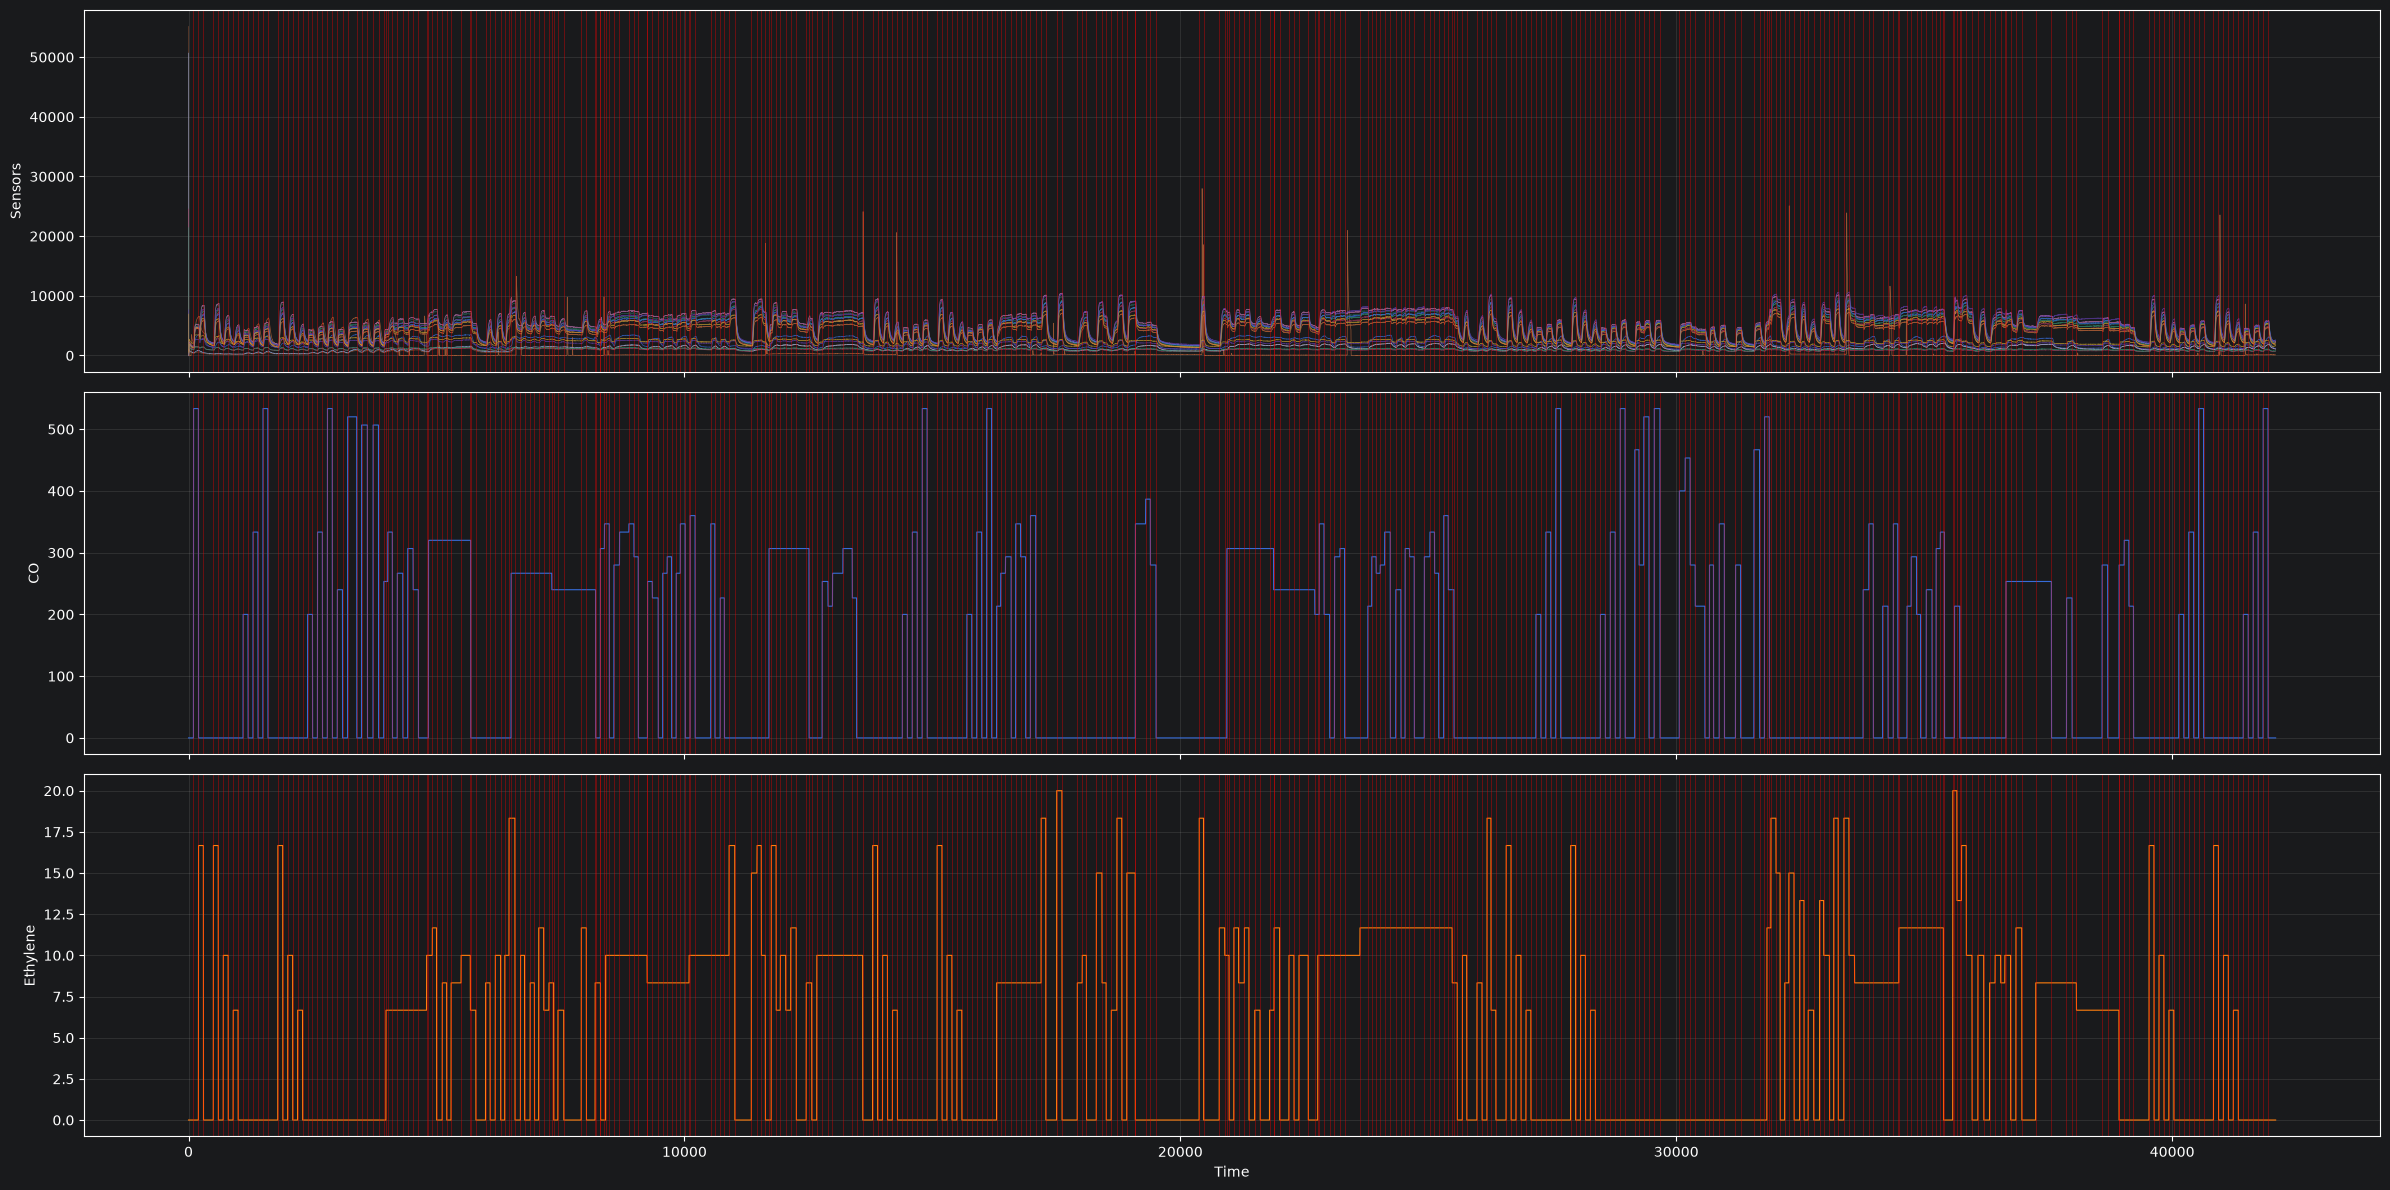

In [19]:
plot_step = 100

fig, axes = plt.subplots(3, 1, figsize=(24, 12), sharex=True)

axes[0].plot(
    time[::plot_step],
        X[::plot_step],
    linewidth=0.5,
    alpha=0.7,
)
axes[0].set_ylabel("Sensors")

axes[1].plot(
    time[::plot_step],
    y[::plot_step, 0],
    linewidth=0.8,
)
axes[1].set_ylabel("CO")

axes[2].plot(
    time[::plot_step],
    y[::plot_step, 1],
    color="tab:orange",
    linewidth=0.8,
)
axes[2].set_ylabel("Ethylene")
axes[2].set_xlabel("Time")

for segment in segments[1:]:
    boundary_time = time[segment["start"]]
    for ax in axes:
        ax.axvline(boundary_time, color="red", linewidth=0.5, alpha=0.5)
        ax.grid(alpha=0.2)

plt.tight_layout()
plt.show()

In [20]:
def make_window_indices(segments, window_size=5000, stride=100):
    samples = []

    for segment in segments:
        segment_start = segment["start"]
        segment_end = segment["end"]

        for end in range(
            segment_start + window_size,
            segment_end + 1,
            stride,
        ):
            start = end - window_size
            samples.append((start, end))

    return samples

In [21]:
generator = np.random.default_rng(42)
indices = generator.permutation(len(segments))

n_train = int(0.70 * len(indices))
n_val = int(0.15 * len(indices))

train_segments = [segments[i] for i in indices[:n_train]]
val_segments = [segments[i] for i in indices[n_train:n_train + n_val]]
test_segments = [segments[i] for i in indices[n_train + n_val:]]

train_samples = make_window_indices(train_segments, window_size=5000, stride=100)
val_samples = make_window_indices(val_segments, window_size=5000, stride=500)
test_samples = make_window_indices(test_segments, window_size=5000, stride=500)

print(
    len(train_samples),
    len(val_samples),
    len(test_samples),
)

17304 748 711


In [22]:
class SensorDataset(Dataset):
    def __init__(self, signals, target, samples):
        self.signals = np.asarray(signals,dtype=np.float32,)
        self.target = np.asarray(target,dtype=np.float32,)
        self.samples = samples

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, index):
        start, end = self.samples[index]

        x = self.signals[start:end].T
        y = self.target[end - 1]

        return torch.from_numpy(x), torch.from_numpy(y)

In [23]:
train_dataset = SensorDataset(X, y, train_samples)
val_dataset = SensorDataset(X, y, val_samples)
test_dataset = SensorDataset(X, y, test_samples)

In [24]:
train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True,
    num_workers=0,
)

val_loader = DataLoader(
    val_dataset,
    batch_size=64,
    shuffle=False,
    num_workers=0,
)

In [25]:
batch_x, batch_y = next(iter(train_loader))

print(batch_x.shape)  # [32, 16, 5000]
print(batch_y.shape)  # [32, 2]

pred = model(batch_x)
print(pred.shape)     # [32, 2]

torch.Size([32, 16, 5000])
torch.Size([32, 2])
torch.Size([32, 2])
